Connected to Python (pygpu-env) (Python 3.11.8)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device : {device}")

Using Device : cuda


In [ ]:
class DifferentiableCanvasV2(nn.Module):
    def __init__(self, canvas_size=128):
        super().__init__()
        self.canvas_size = canvas_size
        y, x = torch.meshgrid(
            torch.linspace(0, 1, canvas_size, device=device),
            torch.linspace(0, 1, canvas_size, device=device),
            indexing='ij'
        )
        self.register_buffer('grid_x', x)
        self.register_buffer('grid_y', y)

    def draw_lines(self, stroke_params, global_blur):
        """
        stroke_params: Shape (N, 6) -> [x1, y1, x2, y2, thickness, opacity]
        """
        canvas = torch.ones((self.canvas_size, self.canvas_size), device=device)
        gx = self.grid_x
        gy = self.grid_y
        
        for i in range(stroke_params.shape[0]):
            x1, y1, x2, y2, thickness, opacity = stroke_params[i]
            
            ax, ay = x2 - x1, y2 - y1
            mag_sq = ax**2 + ay**2 + 1e-6
            
            px, py = gx - x1, gy - y1
            t = torch.clamp((px * ax + py * ay) / mag_sq, 0.0, 1.0)
            
            closest_x = x1 + t * ax
            closest_y = y1 + t * ay
            dist_sq = (gx - closest_x)**2 + (gy - closest_y)**2
            
            # Combine the stroke's desired thickness with the mathematical global blur
            sigma = thickness * 0.02 + global_blur
            
            # Calculate pixel intensity with opacity
            stroke = opacity * torch.exp(-dist_sq / (2 * sigma**2))
            
            canvas = canvas - stroke
            
        return torch.clamp(canvas, min=0.0, max=1.0)

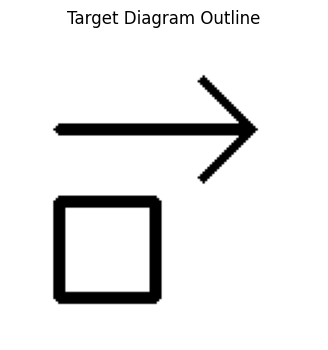

In [ ]:
CANVAS_SIZE = 128
target_img = np.ones((CANVAS_SIZE, CANVAS_SIZE), dtype=np.float32)

cv2.line(target_img, (20, 40), (100, 40), 0.0, 3)   
cv2.line(target_img, (100, 40), (80, 20), 0.0, 3)   
cv2.line(target_img, (100, 40), (80, 60), 0.0, 3)   
cv2.rectangle(target_img, (20, 70), (60, 110), 0.0, 3) 

target_tensor = torch.tensor(target_img, device=device)
plt.figure(figsize=(4, 4))
plt.title("Target Diagram Outline")
plt.imshow(target_tensor.cpu().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
renderer = DifferentiableCanvasV2(canvas_size=CANVAS_SIZE)

# INCREASED CAPACITY: The target has 7 lines, we give the AI 15.
# It must learn to hide the remaining 8 by dropping their opacity to 0.
NUM_STROKES = 15

# Params: [x1, y1, x2, y2, thickness, opacity]
raw_stroke_params = torch.randn((NUM_STROKES, 6), device=device, requires_grad=True)

# Using Adam with a slightly lower learning rate for stable fine-tuning
optimizer = optim.Adam([raw_stroke_params], lr=0.05)

epochs = 1000
losses = []

# Annealing schedule for the mathematical blur
start_blur = 0.15
end_blur = 0.005

print("Starting Simulated Annealing Optimization...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()
    
    # Calculate current global blur (exponential decay)
    progress = epoch / epochs
    current_blur = start_blur * ((end_blur / start_blur) ** progress)
    
    # Map raw parameters to safe bounds [0, 1]
    scaled_params = torch.sigmoid(raw_stroke_params)
    
    rendered_canvas = renderer.draw_lines(scaled_params, global_blur=current_blur)
    
    # Loss combines Pixel MSE and a small penalty to discourage excessive opacity
    # (encourages the AI to use as few strokes as possible)
    mse_loss = nn.MSELoss()(rendered_canvas, target_tensor)
    opacity_penalty = 0.01 * scaled_params[:, 5].mean()
    
    total_loss = mse_loss + opacity_penalty
    
    total_loss.backward()
    optimizer.step()
    
    losses.append(total_loss.item())
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Blur: {current_blur:.4f} | Loss: {total_loss.item():.5f}")

Starting Simulated Annealing Optimization...
Epoch    0 | Blur: 0.1500 | Loss: 0.82079
Epoch  200 | Blur: 0.0760 | Loss: 0.06301
Epoch  400 | Blur: 0.0385 | Loss: 0.04569
Epoch  600 | Blur: 0.0195 | Loss: 0.02658
Epoch  800 | Blur: 0.0099 | Loss: 0.02382
Epoch 1000 | Blur: 0.0050 | Loss: 0.02069


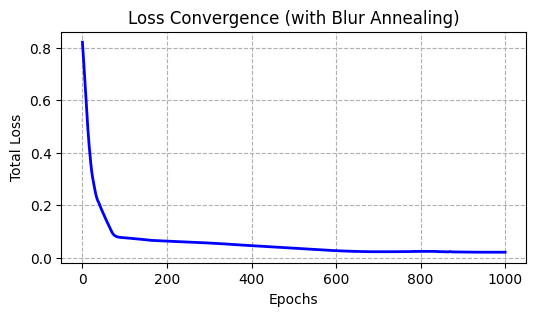

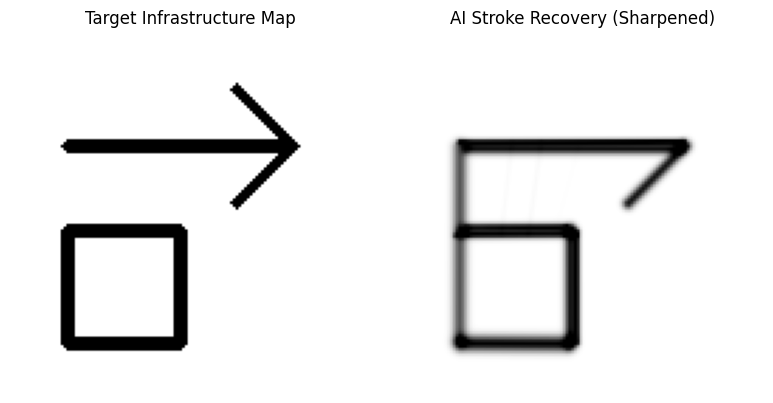

In [ ]:
plt.figure(figsize=(6, 3))
plt.plot(losses, color='blue', lw=2)
plt.title("Loss Convergence (with Blur Annealing)")
plt.xlabel("Epochs")
plt.ylabel("Total Loss")
plt.grid(True, linestyle='--')
plt.show()

# Final render with sharpest blur
with torch.no_grad():
    final_params = torch.sigmoid(raw_stroke_params)
    final_canvas = renderer.draw_lines(final_params, global_blur=end_blur).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target_tensor.cpu().numpy(), cmap='gray')
axes[0].set_title("Target Infrastructure Map")
axes[0].axis('off')

axes[1].imshow(final_canvas, cmap='gray')
axes[1].set_title(f"AI Stroke Recovery (Sharpened)")
axes[1].axis('off')

plt.tight_layout()
plt.show()